# Tier 4 Evaluation: Latent Space Geomtric Validation

In [ ]:
# Purpose:
#   Evaluates whether the β-VAE has learned a biologically coherent latent
#   space by comparing the geometric structure of three representations:
#   (1) raw M-values (input space), (2) latent codes Z_mu (embedding space),
#   and (3) reconstructed M-values (output space).
#
#   HDBSCAN clustering is performed in latent space and projected onto all
#   three UMAP embeddings to ask whether the VAE's learned structure
#   corresponds to known cancer type boundaries.
#
# Sections:
#   4.1  Setup & Data Loading
#   4.2  Dimensionality Reduction
#        4.2a  PCA (diagnostic — explained variance & intrinsic dimensionality)
#        4.2b  UMAP (presentation figure — three-way comparison)
#   4.3  HDBSCAN Clustering in Latent Space
#   4.4  Quantitative Cluster Validation
#        4.4a  ARI / NMI vs known cancer type labels
#        4.4b  Silhouette scores across all three spaces
#        4.4c  kNN overlap between raw and latent space
#   4.5  Presentation Figure
#        Three-panel UMAP: raw / latent / reconstructed, coloured by cancer type
#        with HDBSCAN cluster boundaries overlaid
#
# Inputs (from Tier 1 .npy arrays):
#   - Z_mu_tier1.npy       : posterior means        (N, 92)
#   - X_raw_tier1.npy      : raw M-values           (N, P)
#   - X_hat_tier1.npy      : reconstructed M-values (N, P)
#   - adata.obs            : sample metadata (project_id, split, etc.)
#
# Outputs:
#   - figures/tier4/4_2_pca_explained_variance.png
#   - figures/tier4/4_5_umap_three_panel.png        ← presentation figure
#   - figures/tier4/4_3_hdbscan_latent.png
#   - Printed quantitative summary (ARI, NMI, silhouette, kNN overlap)
#
# How to interpret:
#   Each section contains an INTERPRETATION block explaining what good/bad
#   results look like and what actions to take if results are unexpected.

# 4.1 Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
 
# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)
from sklearn.neighbors import NearestNeighbors
import umap
 
# Clustering
import hdbscan

In [6]:
# Modify these paths to match your environment
ADATA_PATH  = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_cohort_adata.h5ad"
FIGURES_DIR = Path("/ddn_exa/campbell/sli/methylcdm-project/plots/eval_recon/")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
 
CANCER_KEY  = "project_id"   # Column in adata.obs for cancer type labels
RANDOM_SEED = 42

# Cancer type colour palette — consistent across all tiers
CANCER_PALETTE = {
    "TCGA-BLCA": "#E05C5C",
    "TCGA-BRCA": "#5B8DB8",
    "TCGA-GBM":  "#4DAF7C",
    "TCGA-HNSC": "#D4A843",
    "TCGA-KIRC": "#9B6BB5",
}

In [3]:
print("\n[4.1] Loading Tier 1 arrays...")
Z_mu  = np.load("Z_mu_tier1.npy")       # (N, 92) — latent posterior means
X_raw = np.load("X_raw_tier1.npy")      # (N, P)  — raw M-values
X_hat = np.load("X_hat_tier1.npy")      # (N, P)  — reconstructed M-values
 
adata         = ad.read_h5ad(ADATA_PATH)
cancer_labels = adata.obs[CANCER_KEY].values
cancer_types  = sorted(np.unique(cancer_labels))
label_colors  = np.array([CANCER_PALETTE[ct] for ct in cancer_labels])
 
N, P = X_raw.shape
_, L = Z_mu.shape
 
print(f"  Samples        : {N}")
print(f"  Probes         : {P:,}")
print(f"  Latent dims    : {L}")
print(f"  Cancer types   : {cancer_types}")
for ct in cancer_types:
    print(f"    {ct:<15}: {np.sum(cancer_labels == ct)} samples")


[4.1] Loading Tier 1 arrays...
  Samples        : 2118
  Probes         : 225,410
  Latent dims    : 92
  Cancer types   : ['TCGA-BLCA', 'TCGA-BRCA', 'TCGA-GBM', 'TCGA-HNSC', 'TCGA-KIRC']
    TCGA-BLCA      : 408 samples
    TCGA-BRCA      : 756 samples
    TCGA-GBM       : 133 samples
    TCGA-HNSC      : 515 samples
    TCGA-KIRC      : 306 samples


# 4.2a PCA Diagnostic: Explained variance and Intrinsic Dimensionality

In [ ]:
# PCA is run on all three spaces (with aggressive dimensionality reduction for
# raw and reconstructed M-values) to compare the intrinsic dimensionality of
# each representation. The key question is: does the VAE compress the input
# into a lower-dimensional space while preserving the variance structure?
#
# INTERPRETATION:
#   GOOD  — Raw and reconstructed M-values require many PCs to explain 90%
#           of variance (high intrinsic dimensionality). The latent space
#           should explain a similar proportion of variance in far fewer
#           dimensions, confirming the VAE has learned a compact
#           representation. If the latent PCA curve drops steeply, the
#           latent space has concentrated information into a small number
#           of structured dimensions.
#   BAD   — If the latent PCA curve is flat (all dimensions equally
#           informative), the VAE has not learned a hierarchical
#           representation. If raw and reconstructed PCA curves diverge
#           significantly, the VAE has altered the variance structure of
#           the data.

In [4]:
N_PCA_COMPONENTS = 50

In [7]:
print("\n  Running PCA on latent space (Z_mu)...")
pca_latent = PCA(n_components=L, random_state=RANDOM_SEED)
Z_pca      = pca_latent.fit_transform(Z_mu)
latent_var  = pca_latent.explained_variance_ratio_
latent_cum  = np.cumsum(latent_var)
 
n_dims_90_latent = np.searchsorted(latent_cum, 0.90) + 1
n_dims_95_latent = np.searchsorted(latent_cum, 0.95) + 1
print(f"  Latent — dims for 90% variance: {n_dims_90_latent}")
print(f"  Latent — dims for 95% variance: {n_dims_95_latent}")


  Running PCA on latent space (Z_mu)...
  Latent — dims for 90% variance: 11
  Latent — dims for 95% variance: 13


In [8]:
# --- PCA on raw M-values (subsample probes to manage memory) ------------------
print(f"\n  Running PCA on raw M-values (top {N_PCA_COMPONENTS} PCs)...")
pca_raw    = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_raw_pca  = pca_raw.fit_transform(X_raw)
raw_var    = pca_raw.explained_variance_ratio_
raw_cum    = np.cumsum(raw_var)
print(f"  Raw — variance explained by {N_PCA_COMPONENTS} PCs: {raw_cum[-1]:.3f}")


  Running PCA on raw M-values (top 50 PCs)...
  Raw — variance explained by 50 PCs: 0.781


In [9]:
# --- PCA on reconstructed M-values --------------------------------------------
print(f"\n  Running PCA on reconstructed M-values (top {N_PCA_COMPONENTS} PCs)...")
pca_hat    = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_hat_pca  = pca_hat.fit_transform(X_hat)
hat_var    = pca_hat.explained_variance_ratio_
hat_cum    = np.cumsum(hat_var)
print(f"  Reconstructed — variance explained by {N_PCA_COMPONENTS} PCs: {hat_cum[-1]:.3f}")


  Running PCA on reconstructed M-values (top 50 PCs)...
  Reconstructed — variance explained by 50 PCs: 0.987


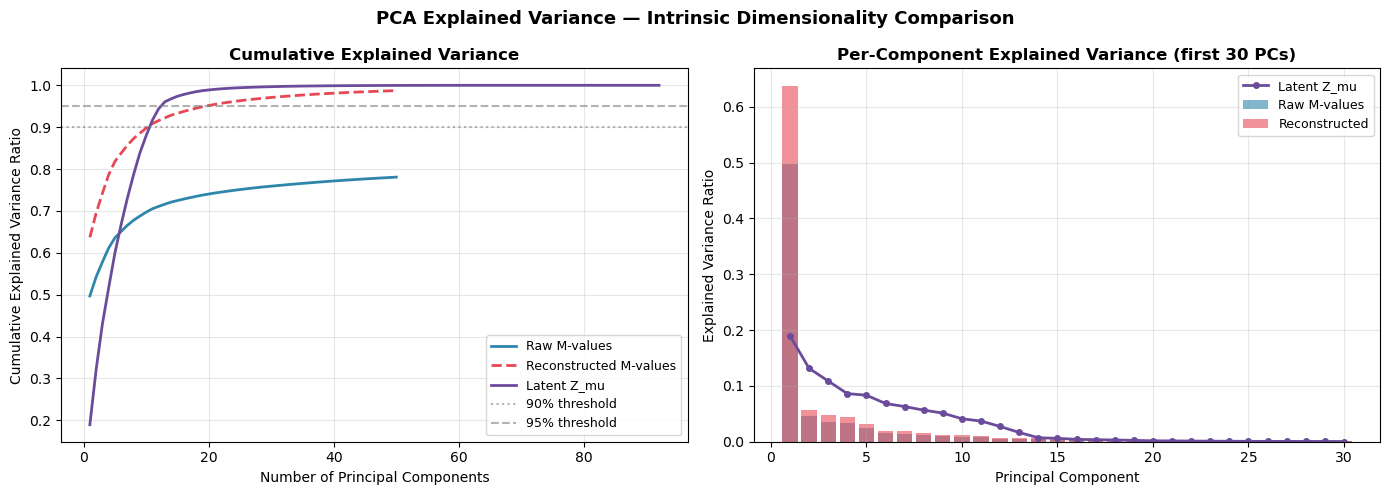


  Figure saved: 4_2a_pca_explained_variance.png


In [10]:
# --- Figure: explained variance curves ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Explained Variance — Intrinsic Dimensionality Comparison",
             fontsize=13, fontweight='bold')
 
# Cumulative explained variance
ax = axes[0]
ax.plot(range(1, len(raw_cum) + 1),    raw_cum,
        color='#2E86AB', linewidth=2.0, label='Raw M-values')
ax.plot(range(1, len(hat_cum) + 1),    hat_cum,
        color='#E84855', linewidth=2.0, label='Reconstructed M-values',
        linestyle='--')
ax.plot(range(1, len(latent_cum) + 1), latent_cum,
        color='#6B4C9A', linewidth=2.0, label='Latent Z_mu')
ax.axhline(0.90, color='gray', linestyle=':', alpha=0.6, label='90% threshold')
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.6, label='95% threshold')
ax.set_title("Cumulative Explained Variance", fontweight='bold')
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance Ratio")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
# Per-component variance (first 30 only for readability)
ax = axes[1]
n_show = 30
ax.bar(range(1, n_show + 1), raw_var[:n_show],
       alpha=0.6, color='#2E86AB', label='Raw M-values', width=0.8)
ax.bar(range(1, n_show + 1), hat_var[:n_show],
       alpha=0.6, color='#E84855', label='Reconstructed', width=0.8)
ax.plot(range(1, L + 1)[:n_show], latent_var[:n_show],
        color='#6B4C9A', linewidth=2.0, marker='o',
        markersize=4, label='Latent Z_mu')
ax.set_title("Per-Component Explained Variance (first 30 PCs)",
             fontweight='bold')
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "4_2a_pca_explained_variance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("\n  Figure saved: 4_2a_pca_explained_variance.png")

# 4.2b UMAP Diagnostic: Three-way Comparison

In [ ]:
# UMAP embeddings are computed for all three spaces:
#   - Raw M-values: PCA-reduced to 50 dims first (standard practice for
#     high-dimensional data — UMAP on 225k dimensions is intractable)
#   - Latent Z_mu: directly, since it is already 92-dimensional
#   - Reconstructed M-values: PCA-reduced to 50 dims first
#
# All three UMAPs use identical hyperparameters so that geometric differences
# between panels reflect differences in the representations, not the embedding.
#
# INTERPRETATION:
#   GOOD  — All three panels show clean separation of cancer types with
#           compact, isotropic clusters. The latent space UMAP should be
#           the cleanest — if it is not, the VAE has not improved upon the
#           raw structure. The reconstructed UMAP should closely resemble
#           the raw UMAP, confirming the decoder preserves the global
#           manifold structure.
#   BAD   — If the latent UMAP shows worse separation than the raw UMAP,
#           the VAE is losing discriminative biological structure in the
#           bottleneck. If the reconstructed UMAP shows worse separation
#           than raw, the decoder is introducing distortions. Filamentous
#           or elongated clusters suggest residual batch effects or
#           technical gradients that the VAE has encoded rather than
#           removed.

In [12]:
# UMAP hyperparameters — identical across all three spaces
UMAP_PARAMS = dict(
    n_neighbors    = 30,
    min_dist       = 0.3,
    n_components   = 2,
    metric         = 'euclidean',
    random_state   = RANDOM_SEED,
    n_jobs         = -1
)

In [13]:
# --- Raw M-values: PCA → UMAP -------------------------------------------------
print("\n  Computing UMAP on raw M-values (via PCA-50)...")
reducer_raw  = umap.UMAP(**UMAP_PARAMS)
umap_raw     = reducer_raw.fit_transform(X_raw_pca)   # Use PCA-50 from above
print(f"  Raw UMAP shape: {umap_raw.shape}")


  Computing UMAP on raw M-values (via PCA-50)...
  Raw UMAP shape: (2118, 2)


In [14]:
# --- Latent Z_mu: direct UMAP -------------------------------------------------
print("\n  Computing UMAP on latent Z_mu (direct)...")
reducer_latent = umap.UMAP(**UMAP_PARAMS)
umap_latent    = reducer_latent.fit_transform(Z_mu)
print(f"  Latent UMAP shape: {umap_latent.shape}")


  Computing UMAP on latent Z_mu (direct)...
  Latent UMAP shape: (2118, 2)


In [15]:
# --- Reconstructed M-values: PCA → UMAP --------------------------------------
print("\n  Computing UMAP on reconstructed M-values (via PCA-50)...")
reducer_hat  = umap.UMAP(**UMAP_PARAMS)
umap_hat     = reducer_hat.fit_transform(X_hat_pca)   # Use PCA-50 from above
print(f"  Reconstructed UMAP shape: {umap_hat.shape}")
 
# Save UMAP coordinates for downstream use
np.save("umap_raw_tier4.npy",    umap_raw)
np.save("umap_latent_tier4.npy", umap_latent)
np.save("umap_hat_tier4.npy",    umap_hat)
print("\n  UMAP coordinates saved.")


  Computing UMAP on reconstructed M-values (via PCA-50)...
  Reconstructed UMAP shape: (2118, 2)

  UMAP coordinates saved.


# 4.3 HBDScan Clustering in Latent Space

In [ ]:
# HDBSCAN is run directly on Z_mu (latent posterior means). HDBSCAN is
# preferred over k-means because:
#   1. It does not require specifying k — the number of clusters is inferred
#   2. It handles non-spherical cluster geometries
#   3. It assigns a noise label (-1) to ambiguous samples, which is
#      biologically informative — these are likely transitional or atypical
#      samples
#
# The resulting cluster labels are compared against known cancer type labels
# using ARI and NMI, and are projected onto all three UMAP panels.
#
# INTERPRETATION:
#   GOOD  — HDBSCAN recovers a number of clusters close to the number of
#           cancer types (5). High ARI (> 0.7) and NMI (> 0.7) indicate
#           strong agreement between the unsupervised clustering and the
#           known cancer type labels — the VAE has organised the latent
#           space according to biology.
#   BAD   — ARI < 0.5 indicates the latent space clusters do not correspond
#           to cancer type labels. This could mean the VAE has organised
#           the space by other biological or technical variables instead.
#           A large fraction of noise samples (label = -1) indicates the
#           latent space manifold is poorly defined.

In [16]:
# HDBSCAN on latent Z_mu
# min_cluster_size: minimum fraction of dataset to form a cluster
# min_samples: controls conservativeness — higher = more noise points
MIN_CLUSTER_SIZE = max(15, int(0.01 * N))   # 1% of dataset, minimum 15
MIN_SAMPLES      = 10
 
print(f"\n  HDBSCAN parameters:")
print(f"  min_cluster_size : {MIN_CLUSTER_SIZE}")
print(f"  min_samples      : {MIN_SAMPLES}")
 
clusterer = hdbscan.HDBSCAN(
    min_cluster_size = MIN_CLUSTER_SIZE,
    min_samples      = MIN_SAMPLES,
    metric           = 'euclidean',
    cluster_selection_method = 'eom',
    prediction_data  = True
)
cluster_labels = clusterer.fit_predict(Z_mu)
 
n_clusters  = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise     = np.sum(cluster_labels == -1)
 
print(f"\n  Clusters found   : {n_clusters}")
print(f"  Noise samples    : {n_noise} ({100 * n_noise / N:.1f}%)")
print(f"  Cluster sizes    :")
for c in sorted(set(cluster_labels)):
    label = f"Cluster {c}" if c >= 0 else "Noise"
    print(f"    {label:<15}: {np.sum(cluster_labels == c)} samples")


  HDBSCAN parameters:
  min_cluster_size : 21
  min_samples      : 10

  Clusters found   : 2
  Noise samples    : 579 (27.3%)
  Cluster sizes    :
    Noise          : 579 samples
    Cluster 0      : 1516 samples
    Cluster 1      : 23 samples


In [17]:
# --- Cluster-to-cancer-type correspondence table ------------------------------
# For each HDBSCAN cluster, show the cancer type composition
print(f"\n  Cluster composition (cancer type breakdown):")
cluster_cancer_df = pd.DataFrame({
    'cluster':     cluster_labels,
    'cancer_type': cancer_labels
})
composition = pd.crosstab(
    cluster_cancer_df['cluster'],
    cluster_cancer_df['cancer_type'],
    normalize='index'
).round(3)
print(f"\n{composition.to_string()}")
 
# Dominant cancer type per cluster
dominant = composition.idxmax(axis=1)
print(f"\n  Dominant cancer type per cluster:")
for idx, ct in dominant.items():
    label = f"Cluster {idx}" if idx >= 0 else "Noise"
    purity = composition.loc[idx, ct]
    print(f"    {label:<15}: {ct} ({purity:.1%} purity)")
 
# Save cluster labels for figure
np.save("hdbscan_labels_tier4.npy", cluster_labels)


  Cluster composition (cancer type breakdown):

cancer_type  TCGA-BLCA  TCGA-BRCA  TCGA-GBM  TCGA-HNSC  TCGA-KIRC
cluster                                                          
-1               0.409      0.299     0.047      0.190      0.055
 0               0.113      0.385     0.070      0.252      0.181
 1               0.000      0.000     0.000      1.000      0.000

  Dominant cancer type per cluster:
    Noise          : TCGA-BLCA (40.9% purity)
    Cluster 0      : TCGA-BRCA (38.5% purity)
    Cluster 1      : TCGA-HNSC (100.0% purity)


# 4.4 Quantitative Cluster Validation

In [ ]:
# Computes ARI, NMI, silhouette scores, and kNN overlap to quantify how well
# the geometric structure of each space corresponds to known biology.
#
# INTERPRETATION:
#   ARI   — Adjusted Rand Index. Range [-1, 1]. Values > 0.7 indicate strong
#           agreement. 1.0 = perfect match. 0.0 = random.
#   NMI   — Normalized Mutual Information. Range [0, 1]. Values > 0.7
#           indicate strong agreement.
#   Silhouette — Range [-1, 1]. Higher = more compact, well-separated
#           clusters. Compare across spaces — the latent space should have
#           the highest silhouette score if the VAE has improved structure.
#   kNN overlap — Proportion of each sample's k nearest neighbours shared
#           between raw and latent space. High overlap means the VAE
#           preserved local neighbourhood structure.

In [18]:
# Exclude noise samples for ARI/NMI computation
valid_mask      = cluster_labels != -1
labels_valid    = cluster_labels[valid_mask]
cancer_valid    = cancer_labels[valid_mask]
 
ari = adjusted_rand_score(cancer_valid, labels_valid)
nmi = normalized_mutual_info_score(cancer_valid, labels_valid)
 
print(f"\n  Cluster vs Cancer Type Agreement (noise excluded):")
print(f"  ARI : {ari:.4f}  {'[STRONG]' if ari > 0.7 else '[MODERATE]' if ari > 0.5 else '[WEAK]'}")
print(f"  NMI : {nmi:.4f}  {'[STRONG]' if nmi > 0.7 else '[MODERATE]' if nmi > 0.5 else '[WEAK]'}")


  Cluster vs Cancer Type Agreement (noise excluded):
  ARI : 0.0007  [WEAK]
  NMI : 0.0265  [WEAK]


In [19]:
# --- Silhouette scores in each space ------------------------------------------
# Use UMAP coordinates for silhouette (PCA-50 for raw/recon, direct for latent)
print(f"\n  Silhouette Scores (cancer type labels):")
 
# Integer encode cancer labels for sklearn
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cancer_int = le.fit_transform(cancer_labels)
 
sil_raw    = silhouette_score(umap_raw,    cancer_int, random_state=RANDOM_SEED)
sil_latent = silhouette_score(umap_latent, cancer_int, random_state=RANDOM_SEED)
sil_hat    = silhouette_score(umap_hat,    cancer_int, random_state=RANDOM_SEED)
 
print(f"  Raw M-values (UMAP)        : {sil_raw:.4f}")
print(f"  Latent Z_mu  (UMAP)        : {sil_latent:.4f}")
print(f"  Reconstructed M-values (UMAP): {sil_hat:.4f}")
 
best_space = max(
    [('Raw', sil_raw), ('Latent', sil_latent), ('Reconstructed', sil_hat)],
    key=lambda x: x[1]
)[0]
print(f"\n  Best separated space: {best_space}")
if best_space == 'Latent':
    print("  [GOOD] VAE has improved upon the raw structure.")
elif best_space == 'Raw':
    print("  [WARNING] VAE has not improved upon raw structure in UMAP space.")


  Silhouette Scores (cancer type labels):
  Raw M-values (UMAP)        : 0.1592
  Latent Z_mu  (UMAP)        : 0.0781
  Reconstructed M-values (UMAP): 0.1028

  Best separated space: Raw
  [WARNING] VAE has not improved upon raw structure in UMAP space.


In [20]:
# --- kNN overlap: raw vs latent space -----------------------------------------
# Measures how well the VAE preserves local neighbourhood structure
print(f"\n  kNN Neighbourhood Overlap (raw PCA-50 vs latent Z_mu):")
 
K = 10
nn_raw    = NearestNeighbors(n_neighbors=K + 1, metric='euclidean', n_jobs=-1)
nn_latent = NearestNeighbors(n_neighbors=K + 1, metric='euclidean', n_jobs=-1)
 
nn_raw.fit(X_raw_pca)
nn_latent.fit(Z_mu)
 
_, idx_raw    = nn_raw.kneighbors(X_raw_pca)
_, idx_latent = nn_latent.kneighbors(Z_mu)
 
# Exclude self (index 0) and compute overlap
overlaps = []
for i in range(N):
    raw_nbrs    = set(idx_raw[i, 1:])
    latent_nbrs = set(idx_latent[i, 1:])
    overlaps.append(len(raw_nbrs & latent_nbrs) / K)
 
mean_overlap = np.mean(overlaps)
print(f"  Mean kNN overlap (k={K}): {mean_overlap:.4f} "
      f"({mean_overlap * 100:.1f}% of neighbours shared)")
print(f"  {'[GOOD]' if mean_overlap > 0.5 else '[WARNING: local structure not well preserved]'}")


  kNN Neighbourhood Overlap (raw PCA-50 vs latent Z_mu):
  Mean kNN overlap (k=10): 0.6506 (65.1% of neighbours shared)
  [GOOD]


# 4.5 Presentation Figure - Three-panel UMAP

In [ ]:
# Publication-quality three-panel UMAP figure coloured by cancer type.
# HDBSCAN cluster boundaries are drawn as convex hulls around each cluster
# in the latent space panel. The same hull coordinates are projected onto
# the raw and reconstructed panels to visualise whether the clustering
# generalises across spaces.
#
# Layout: Raw | Latent | Reconstructed
#
# INTERPRETATION:
#   The figure should be read left to right as a narrative:
#   "This is the structure in the input data (raw), this is what the VAE
#   learned to represent (latent), and this is what the decoder produces
#   (reconstructed)." Increasing separation and compactness from left to
#   right is the ideal story.

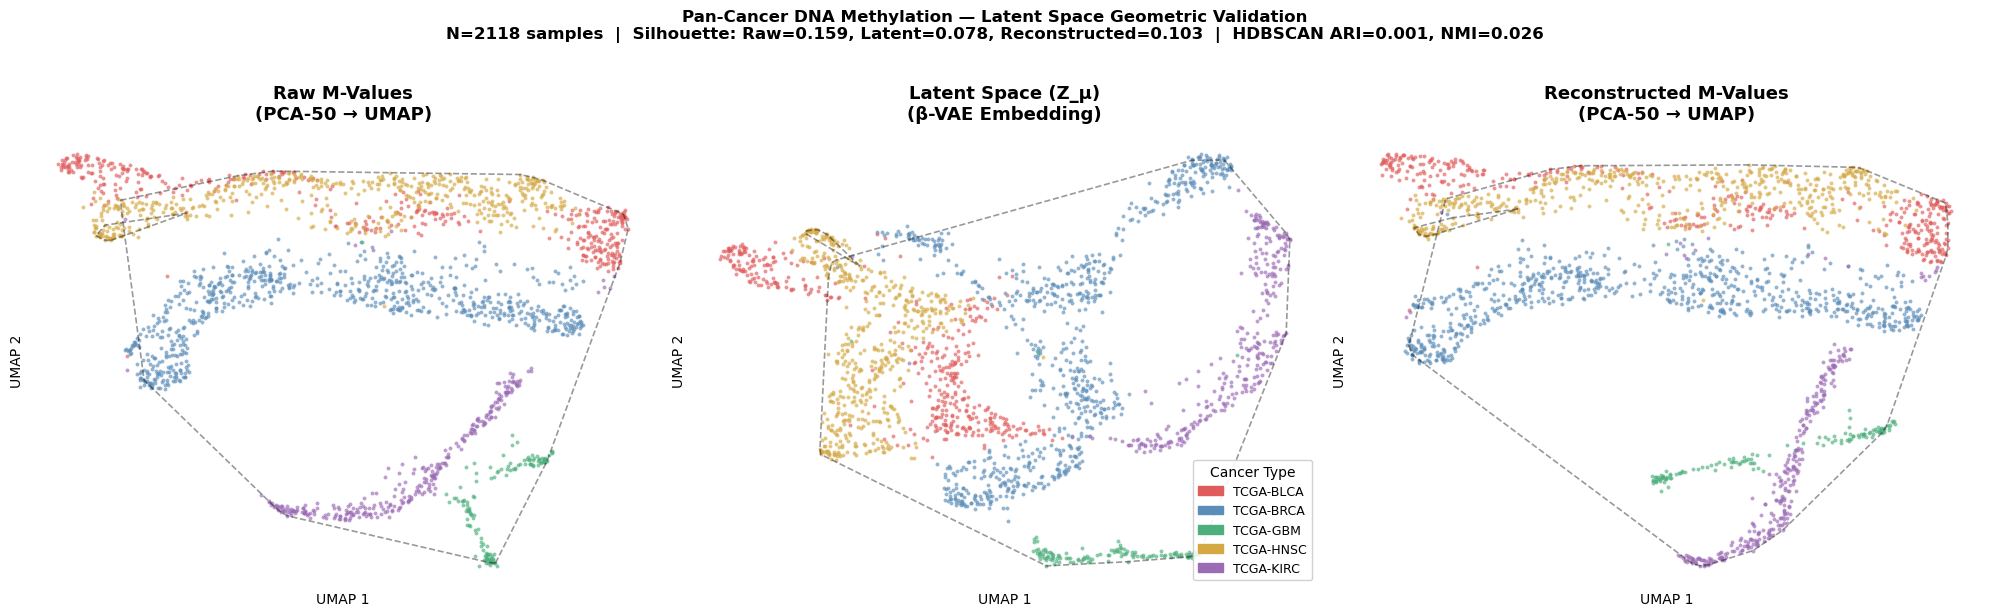


  Presentation figure saved: 4_5_umap_three_panel.png


In [21]:
from scipy.spatial import ConvexHull
 
def plot_umap_panel(ax, umap_coords, color_labels, palette,
                    title, show_legend=False,
                    cluster_labels_overlay=None,
                    hdbscan_umap_coords=None):
    """
    Plots a single UMAP panel with cancer type colouring.
 
    Parameters
    ----------
    ax                    : matplotlib axis
    umap_coords           : (N, 2) UMAP embedding
    color_labels          : cancer type labels for colouring
    palette               : dict mapping cancer type → hex colour
    title                 : panel title
    show_legend           : whether to draw the cancer type legend
    cluster_labels_overlay: HDBSCAN cluster labels for convex hull overlay
    hdbscan_umap_coords   : UMAP coords to use for hull computation
                            (should be latent UMAP for all panels)
    """
    # Plot points
    for ct in sorted(palette.keys()):
        mask = color_labels == ct
        ax.scatter(
            umap_coords[mask, 0],
            umap_coords[mask, 1],
            c      = palette[ct],
            s      = 8,
            alpha  = 0.65,
            linewidths = 0,
            label  = ct,
            rasterized = True
        )
 
    # Draw HDBSCAN convex hulls if provided
    if cluster_labels_overlay is not None and hdbscan_umap_coords is not None:
        unique_clusters = sorted(set(cluster_labels_overlay))
        hull_colors = plt.cm.Set2(np.linspace(0, 1, len(unique_clusters)))
        for c_idx, c in enumerate(unique_clusters):
            if c == -1:
                continue
            mask = cluster_labels_overlay == c
            pts  = hdbscan_umap_coords[mask]
            if len(pts) < 4:
                continue
            try:
                hull = ConvexHull(pts)
                hull_pts = pts[hull.vertices]
                hull_pts = np.vstack([hull_pts, hull_pts[0]])  # Close the hull
                ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                        color='black', linewidth=1.2, alpha=0.4,
                        linestyle='--')
            except Exception:
                pass
 
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel("UMAP 1", fontsize=10)
    ax.set_ylabel("UMAP 2", fontsize=10)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
 
    # Remove spines for cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
 
    if show_legend:
        legend_handles = [
            mpatches.Patch(color=palette[ct], label=ct)
            for ct in sorted(palette.keys())
        ]
        ax.legend(
            handles    = legend_handles,
            title      = "Cancer Type",
            title_fontsize = 10,
            fontsize   = 9,
            loc        = 'lower right',
            framealpha = 0.9,
            edgecolor  = '#CCCCCC'
        )
 
# --- Build the three-panel figure ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')
 
# Subtitle with key quantitative metrics
subtitle = (f"N={N} samples  |  Silhouette: Raw={sil_raw:.3f}, "
            f"Latent={sil_latent:.3f}, Reconstructed={sil_hat:.3f}  |  "
            f"HDBSCAN ARI={ari:.3f}, NMI={nmi:.3f}")
 
fig.suptitle(
    f"Pan-Cancer DNA Methylation — Latent Space Geometric Validation\n{subtitle}",
    fontsize=12, fontweight='bold', y=1.02
)
 
# Panel 1: Raw M-values
plot_umap_panel(
    ax                    = axes[0],
    umap_coords           = umap_raw,
    color_labels          = cancer_labels,
    palette               = CANCER_PALETTE,
    title                 = "Raw M-Values\n(PCA-50 → UMAP)",
    show_legend           = False,
    cluster_labels_overlay = cluster_labels,
    hdbscan_umap_coords   = umap_raw
)
 
# Panel 2: Latent Z_mu — show legend here (centre panel)
plot_umap_panel(
    ax                    = axes[1],
    umap_coords           = umap_latent,
    color_labels          = cancer_labels,
    palette               = CANCER_PALETTE,
    title                 = "Latent Space (Z_μ)\n(β-VAE Embedding)",
    show_legend           = True,
    cluster_labels_overlay = cluster_labels,
    hdbscan_umap_coords   = umap_latent
)
 
# Panel 3: Reconstructed M-values
plot_umap_panel(
    ax                    = axes[2],
    umap_coords           = umap_hat,
    color_labels          = cancer_labels,
    palette               = CANCER_PALETTE,
    title                 = "Reconstructed M-Values\n(PCA-50 → UMAP)",
    show_legend           = False,
    cluster_labels_overlay = cluster_labels,
    hdbscan_umap_coords   = umap_hat
)
 
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "4_5_umap_three_panel.png",
    dpi=200, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("\n  Presentation figure saved: 4_5_umap_three_panel.png")

# Supplementary: HDBScan Cluster Assignment

In [ ]:
# Same three-panel layout but coloured by HDBSCAN cluster assignment rather
# than cancer type. Noise samples (cluster = -1) are shown in light grey.
# This makes the cluster boundaries directly visible.

In [24]:
MIN_CLUSTER_SIZE = max(15, int(0.01 * N))
MIN_SAMPLES      = 10

In [25]:
def run_hdbscan(data, space_name):
    """
    Runs HDBSCAN on the given data matrix and prints a summary.
 
    Parameters
    ----------
    data       : np.ndarray, shape (N, D) — input to cluster
    space_name : str — label for printing
 
    Returns
    -------
    labels     : np.ndarray, shape (N,) — cluster assignments (-1 = noise)
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size         = MIN_CLUSTER_SIZE,
        min_samples              = MIN_SAMPLES,
        metric                   = 'euclidean',
        cluster_selection_method = 'eom',
        prediction_data          = True
    )
    labels      = clusterer.fit_predict(data)
    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise     = np.sum(labels == -1)
 
    print(f"\n  [{space_name}]")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Noise samples  : {n_noise} ({100 * n_noise / N:.1f}%)")
 
    # Cancer type composition per cluster
    df = pd.DataFrame({'cluster': labels, 'cancer_type': cancer_labels})
    composition = pd.crosstab(
        df['cluster'], df['cancer_type'], normalize='index'
    ).round(3)
 
    dominant = composition.idxmax(axis=1)
    print(f"  Dominant cancer type per cluster:")
    for idx, ct in dominant.items():
        label   = f"Cluster {idx}" if idx >= 0 else "Noise"
        purity  = composition.loc[idx, ct]
        n_samp  = np.sum(labels == idx)
        print(f"    {label:<15}: {ct:<15} ({purity:.1%} purity, n={n_samp})")
 
    return labels, n_clusters, n_noise
 

In [26]:
# --- Run HDBSCAN in each space ------------------------------------------------
labels_raw,    n_raw,    noise_raw    = run_hdbscan(X_raw_pca, "Raw M-values (PCA-50)")
labels_latent, n_latent, noise_latent = run_hdbscan(Z_mu,      "Latent Z_mu")
labels_hat,    n_hat,    noise_hat    = run_hdbscan(X_hat_pca, "Reconstructed M-values (PCA-50)")
 
# Save all three for downstream use
np.save("hdbscan_labels_raw_tier4.npy",    labels_raw)
np.save("hdbscan_labels_latent_tier4.npy", labels_latent)
np.save("hdbscan_labels_hat_tier4.npy",    labels_hat)


  [Raw M-values (PCA-50)]
  Clusters found : 7
  Noise samples  : 1377 (65.0%)
  Dominant cancer type per cluster:
    Noise          : TCGA-BRCA       (38.7% purity, n=1377)
    Cluster 0      : TCGA-GBM        (100.0% purity, n=24)
    Cluster 1      : TCGA-BLCA       (100.0% purity, n=88)
    Cluster 2      : TCGA-GBM        (100.0% purity, n=28)
    Cluster 3      : TCGA-BRCA       (100.0% purity, n=221)
    Cluster 4      : TCGA-HNSC       (99.0% purity, n=196)
    Cluster 5      : TCGA-KIRC       (100.0% purity, n=42)
    Cluster 6      : TCGA-KIRC       (100.0% purity, n=142)

  [Latent Z_mu]
  Clusters found : 2
  Noise samples  : 579 (27.3%)
  Dominant cancer type per cluster:
    Noise          : TCGA-BLCA       (40.9% purity, n=579)
    Cluster 0      : TCGA-BRCA       (38.5% purity, n=1516)
    Cluster 1      : TCGA-HNSC       (100.0% purity, n=23)

  [Reconstructed M-values (PCA-50)]
  Clusters found : 2
  Noise samples  : 850 (40.1%)
  Dominant cancer type per cluster:
 

# 4.4 Quantitative Cluster Validation

In [27]:
def compute_cluster_metrics(labels, cancer_labels, space_name):
    """
    Computes ARI, NMI, and silhouette score for a given clustering.
    Excludes noise samples (label = -1) from ARI/NMI computation.
    """
    valid_mask    = labels != -1
    labels_valid  = labels[valid_mask]
    cancer_valid  = cancer_labels[valid_mask]
 
    if len(set(labels_valid)) < 2:
        print(f"  {space_name:<35}: insufficient clusters for ARI/NMI")
        return None, None
 
    ari = adjusted_rand_score(cancer_valid, labels_valid)
    nmi = normalized_mutual_info_score(cancer_valid, labels_valid)
    print(f"  {space_name:<35}: ARI={ari:.4f}  NMI={nmi:.4f}  "
          f"{'[STRONG]' if ari > 0.7 else '[MODERATE]' if ari > 0.5 else '[WEAK]'}")
    return ari, nmi

In [28]:
print(f"\n  ARI / NMI vs Known Cancer Type Labels (noise excluded):")
ari_raw,    nmi_raw    = compute_cluster_metrics(labels_raw,    cancer_labels, "Raw M-values (PCA-50)")
ari_latent, nmi_latent = compute_cluster_metrics(labels_latent, cancer_labels, "Latent Z_mu")
ari_hat,    nmi_hat    = compute_cluster_metrics(labels_hat,    cancer_labels, "Reconstructed (PCA-50)")
 


  ARI / NMI vs Known Cancer Type Labels (noise excluded):
  Raw M-values (PCA-50)              : ARI=0.9224  NMI=0.9332  [STRONG]
  Latent Z_mu                        : ARI=0.0007  NMI=0.0265  [WEAK]
  Reconstructed (PCA-50)             : ARI=0.0266  NMI=0.0847  [WEAK]


In [29]:
# Silhouette scores on UMAP coordinates
print(f"\n  Silhouette Scores (UMAP coordinates, cancer type labels):")
sil_raw    = silhouette_score(umap_raw,    cancer_int, random_state=RANDOM_SEED)
sil_latent = silhouette_score(umap_latent, cancer_int, random_state=RANDOM_SEED)
sil_hat    = silhouette_score(umap_hat,    cancer_int, random_state=RANDOM_SEED)
print(f"  Raw M-values        : {sil_raw:.4f}")
print(f"  Latent Z_mu         : {sil_latent:.4f}")
print(f"  Reconstructed       : {sil_hat:.4f}")


  Silhouette Scores (UMAP coordinates, cancer type labels):
  Raw M-values        : 0.1592
  Latent Z_mu         : 0.0781
  Reconstructed       : 0.1028


In [30]:
best_space = max(
    [('Raw', sil_raw), ('Latent', sil_latent), ('Reconstructed', sil_hat)],
    key=lambda x: x[1]
)[0]
print(f"\n  Best separated space: {best_space}")
if best_space == 'Latent':
    print("  [GOOD] VAE has improved upon the raw structure.")
else:
    print(f"  [NOTE] {best_space} space has highest silhouette — "
          f"VAE has not improved geometric separability.")


  Best separated space: Raw
  [NOTE] Raw space has highest silhouette — VAE has not improved geometric separability.


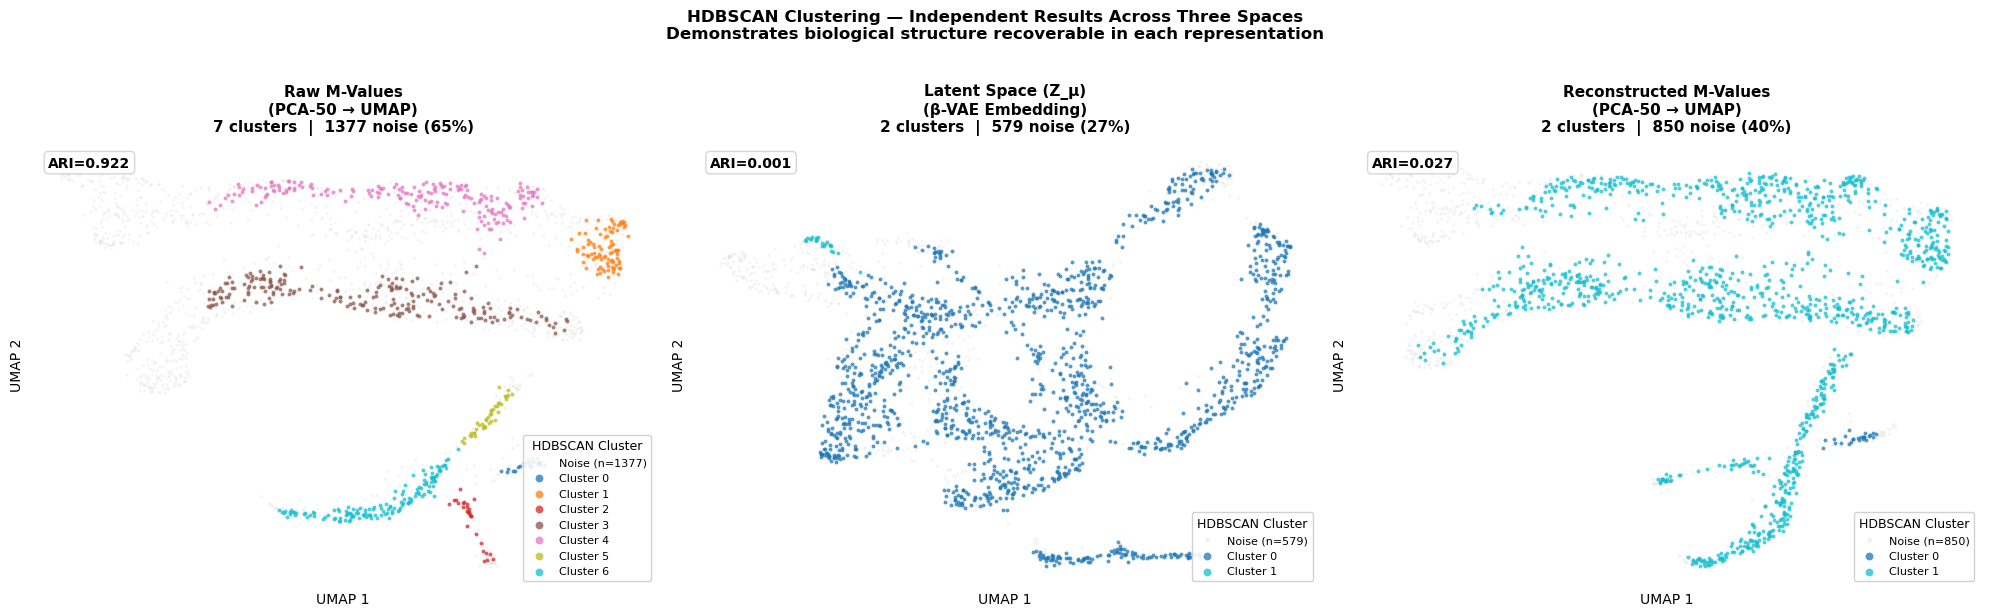


  Figure saved: 4_5b_hdbscan_independent.png


In [33]:
def build_cluster_palette(labels):
    """Builds a colour palette for HDBSCAN cluster labels."""
    unique  = sorted(set(labels))
    n_real  = len([c for c in unique if c >= 0])
    cmap    = plt.cm.tab10(np.linspace(0, 1, max(n_real, 1)))
    palette = {c: cmap[i] for i, c in enumerate([c for c in unique if c >= 0])}
    palette[-1] = np.array([0.85, 0.85, 0.85, 0.35])   # Grey for noise
    return palette
 
def plot_hdbscan_panel(ax, umap_coords, cluster_labels, palette,
                       title, n_clusters, n_noise, ari, show_legend=False):
    """Plots a single HDBSCAN panel with cluster colouring."""
    unique_clusters = sorted(set(cluster_labels))
 
    for c in unique_clusters:
        mask  = cluster_labels == c
        color = palette[c]
        label = f"Cluster {c}" if c >= 0 else f"Noise (n={n_noise})"
        ax.scatter(
            umap_coords[mask, 0],
            umap_coords[mask, 1],
            c          = [color],
            s          = 8 if c >= 0 else 4,
            alpha      = 0.75 if c >= 0 else 0.3,
            linewidths = 0,
            label      = label,
            rasterized = True
        )
 
    # ARI annotation in corner
    ari_str = f"ARI={ari:.3f}" if ari is not None else "ARI=N/A"
    ax.text(
        0.03, 0.97, ari_str,
        transform   = ax.transAxes,
        fontsize    = 10,
        fontweight  = 'bold',
        va          = 'top',
        ha          = 'left',
        bbox        = dict(boxstyle='round,pad=0.3',
                           facecolor='white', alpha=0.8, edgecolor='#CCCCCC')
    )
 
    subtitle = f"{n_clusters} cluster{'s' if n_clusters != 1 else ''}  |  {n_noise} noise ({100*n_noise/N:.0f}%)"
    ax.set_title(f"{title}\n{subtitle}", fontweight='bold', fontsize=11, pad=8)
    ax.set_xlabel("UMAP 1", fontsize=10)
    ax.set_ylabel("UMAP 2", fontsize=10)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
 
    if show_legend:
        ax.legend(
            title          = 'HDBSCAN Cluster',
            title_fontsize = 9,
            fontsize       = 8,
            loc            = 'lower right',
            framealpha     = 0.9,
            edgecolor      = '#CCCCCC',
            markerscale    = 2.0
        )
 
# Build per-space palettes
palette_raw    = build_cluster_palette(labels_raw)
palette_latent = build_cluster_palette(labels_latent)
palette_hat    = build_cluster_palette(labels_hat)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')
fig.suptitle(
    "HDBSCAN Clustering — Independent Results Across Three Spaces\n"
    "Demonstrates biological structure recoverable in each representation",
    fontsize=12, fontweight='bold', y=1.02
)
 
plot_hdbscan_panel(
    ax              = axes[0],
    umap_coords     = umap_raw,
    cluster_labels  = labels_raw,
    palette         = palette_raw,
    title           = "Raw M-Values\n(PCA-50 → UMAP)",
    n_clusters      = n_raw,
    n_noise         = noise_raw,
    ari             = ari_raw,
    show_legend     = True
)
 
plot_hdbscan_panel(
    ax              = axes[1],
    umap_coords     = umap_latent,
    cluster_labels  = labels_latent,
    palette         = palette_latent,
    title           = "Latent Space (Z_μ)\n(β-VAE Embedding)",
    n_clusters      = n_latent,
    n_noise         = noise_latent,
    ari             = ari_latent,
    show_legend     = True
)
 
plot_hdbscan_panel(
    ax              = axes[2],
    umap_coords     = umap_hat,
    cluster_labels  = labels_hat,
    palette         = palette_hat,
    title           = "Reconstructed M-Values\n(PCA-50 → UMAP)",
    n_clusters      = n_hat,
    n_noise         = noise_hat,
    ari             = ari_hat,
    show_legend     = True
)
 
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "4_5b_hdbscan_independent.png",
    dpi=200, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("\n  Figure saved: 4_5b_hdbscan_independent.png")

In [32]:
# --- Comparison summary table -------------------------------------------------
print("\n  Comparison Summary:")
print(f"  {'Space':<35} {'Clusters':>8} {'Noise %':>8} {'ARI':>8} {'NMI':>8} {'Silhouette':>12}")
print(f"  {'-'*83}")
for name, n_c, n_no, ari, nmi, sil in [
    ("Raw M-values (PCA-50)",     n_raw,    noise_raw,    ari_raw,    nmi_raw,    sil_raw),
    ("Latent Z_mu",               n_latent, noise_latent, ari_latent, nmi_latent, sil_latent),
    ("Reconstructed M-values",    n_hat,    noise_hat,    ari_hat,    nmi_hat,    sil_hat),
]:
    ari_str = f"{ari:.4f}" if ari is not None else "  N/A"
    nmi_str = f"{nmi:.4f}" if nmi is not None else "  N/A"
    print(f"  {name:<35} {n_c:>8} {100*n_no/N:>7.1f}% {ari_str:>8} {nmi_str:>8} {sil:>12.4f}")


  Comparison Summary:
  Space                               Clusters  Noise %      ARI      NMI   Silhouette
  -----------------------------------------------------------------------------------
  Raw M-values (PCA-50)                      7    65.0%   0.9224   0.9332       0.1592
  Latent Z_mu                                2    27.3%   0.0007   0.0265       0.0781
  Reconstructed M-values                     2    40.1%   0.0266   0.0847       0.1028


# Tier 4 Summary

In [23]:
print("\n" + "=" * 70)
print("TIER 4 SUMMARY")
print("=" * 70)
print(f"""
  Section   Metric                              Value
  -------   ----------------------------------  --------------------
  4.2a      Latent dims for 90% PCA variance   {n_dims_90_latent}
  4.2a      Latent dims for 95% PCA variance   {n_dims_95_latent}
  4.3       HDBSCAN clusters found             {n_clusters}
  4.3       Noise samples                      {n_noise} ({100*n_noise/N:.1f}%)
  4.4       ARI (clusters vs cancer type)      {ari:.4f}
  4.4       NMI (clusters vs cancer type)      {nmi:.4f}
  4.4       Silhouette — Raw                   {sil_raw:.4f}
  4.4       Silhouette — Latent                {sil_latent:.4f}
  4.4       Silhouette — Reconstructed         {sil_hat:.4f}
  4.4       kNN overlap (k={K}, raw vs latent)  {mean_overlap:.4f}
 
  Figures saved to: {FIGURES_DIR}/
    4_2a_pca_explained_variance.png
    4_5_umap_three_panel.png          ← presentation figure
    4_5b_umap_hdbscan_clusters.png    ← supplementary
""")


TIER 4 SUMMARY

  Section   Metric                              Value
  -------   ----------------------------------  --------------------
  4.2a      Latent dims for 90% PCA variance   11
  4.2a      Latent dims for 95% PCA variance   13
  4.3       HDBSCAN clusters found             2
  4.3       Noise samples                      579 (27.3%)
  4.4       ARI (clusters vs cancer type)      0.0007
  4.4       NMI (clusters vs cancer type)      0.0265
  4.4       Silhouette — Raw                   0.1592
  4.4       Silhouette — Latent                0.0781
  4.4       Silhouette — Reconstructed         0.1028
  4.4       kNN overlap (k=10, raw vs latent)  0.6506

  Figures saved to: /ddn_exa/campbell/sli/methylcdm-project/plots/eval_recon/
    4_2a_pca_explained_variance.png
    4_5_umap_three_panel.png          ← presentation figure
    4_5b_umap_hdbscan_clusters.png    ← supplementary

